In [1]:
import sys
sys.path.insert(0, ".")
from detection.detect import run_bls_all

result = run_bls_all()
print(result)

Found 23 processed stars. Running BLS on each...
[1/23] TIC 267168728: not significant (power=0.00002)
[2/23] TIC 267194964: not significant (power=0.00000)
[3/23] TIC 270278779: not significant (power=0.00001)
[4/23] TIC 274228124: not significant (power=0.00001)
[5/23] TIC 279799236: not significant (power=0.00003)
[6/23] TIC 302994978: not significant (power=0.00024)
[7/23] TIC 317328068: not significant (power=0.00003)
[8/23] TIC 317351809: not significant (power=0.00014)
[9/23] TIC 323434598: not significant (power=0.00005)
[10/23] TIC 323445628: not significant (power=0.00010)
[11/23] TIC 369780272: not significant (power=0.00010)
[12/23] TIC 369894394: CANDIDATE (power=0.00239, period=0.525d)
[13/23] TIC 377023600: not significant (power=0.00012)
[14/23] TIC 388242391: not significant (power=0.00001)
[15/23] TIC 397233096: not significant (power=0.00002)
[16/23] TIC 405459430: not significant (power=0.00010)
[17/23] TIC 405465759: not significant (power=0.00003)
[18/23] TIC 4054

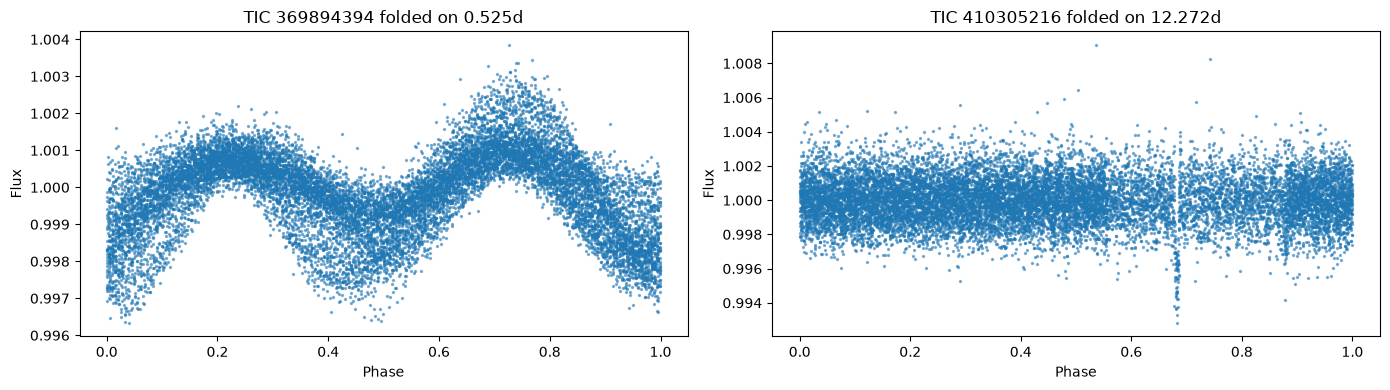

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from detection.detect import load_processed_star

candidates = [
    ("369894394", 0.525),
    ("410305216", 12.272),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (tic_id, period) in zip(axes, candidates):
    time, flux = load_processed_star(f"data/processed/TIC_{tic_id}.npy")
    phase = (time % period) / period
    sort_idx = np.argsort(phase)
    ax.scatter(phase[sort_idx], flux[sort_idx], s=2, alpha=0.5)
    ax.set_title(f"TIC {tic_id} folded on {period}d")
    ax.set_xlabel("Phase")
    ax.set_ylabel("Flux")

plt.tight_layout()
plt.show()

In [1]:
import sys
sys.path.insert(0, ".")
from preprocessing.target_selector import filter_catalog, save_target_list

targets = filter_catalog(
    "D:\exoplanet-detector\tic_dec68_00S__66_00S.csv.gz",  # wherever you saved it
    max_tmag=12.0,
    num_targets=700
)
save_target_list(targets, out_filename="target_list_cvz.csv")

<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Herry\AppData\Local\Temp\ipykernel_22192\2221842122.py:6: SyntaxWarning: invalid escape sequence '\e'
  "D:\exoplanet-detector\tic_dec68_00S__66_00S.csv.gz",  # wherever you saved it


OSError: [Errno 22] Invalid argument: 'D:\\exoplanet-detector\tic_dec68_00S__66_00S.csv.gz'

In [2]:
import sys
sys.path.insert(0, ".")
from preprocessing.target_selector import filter_catalog, save_target_list

targets = filter_catalog(
    "D:/exoplanet-detector/tic_dec68_00S__66_00S.csv.gz",
    max_tmag=12.0,
    num_targets=700
)
save_target_list(targets, out_filename="target_list_cvz.csv")

Scanned 423280 rows from catalog.
  Skipped (wrong object type): 8877
  Skipped (too faint, Tmag > 12.0): 413702
  Skipped (malformed row): 0
  Selected: 700 target stars
Saved 700 targets to data/targets\target_list_cvz.csv


'data/targets\\target_list_cvz.csv'

In [3]:
import lightkurve as lk
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

targets = pd.read_csv("data/targets/target_list_cvz.csv")
sample_ids = targets["TIC_ID"].astype(str).tolist()[:30]

def check_one(tic):
    sectors_found = []
    try:
        search = lk.search_lightcurve(f"TIC {tic}", mission="TESS", author="SPOC", cadence="short")
        for row in search:
            sectors_found.append(row.mission[0])
    except Exception:
        pass
    return sectors_found

sector_counts = {}
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = [executor.submit(check_one, tic) for tic in sample_ids]
    for i, future in enumerate(as_completed(futures)):
        sectors = future.result()
        for sector in sectors:
            sector_counts[sector] = sector_counts.get(sector, 0) + 1
        print(f"Checked {i+1}/30")

print()
for sector, count in sorted(sector_counts.items(), key=lambda x: -x[1]):
    print(f"{sector}: {count} stars have 2-min SPOC data")

C:\Users\Herry\AppData\Roaming\Python\Python313\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Checked 1/30
Checked 2/30
Checked 3/30
Checked 4/30
Checked 5/30
Checked 6/30
Checked 7/30
Checked 8/30
Checked 9/30
Checked 10/30
Checked 11/30
Checked 12/30
Checked 13/30
Checked 14/30
Checked 15/30
Checked 16/30
Checked 17/30
Checked 18/30
Checked 19/30
Checked 20/30
Checked 21/30
Checked 22/30
Checked 23/30
Checked 24/30
Checked 25/30


Checked 26/30
Checked 27/30
Checked 28/30
Checked 29/30
Checked 30/30

TESS Sector 39: 3 stars have 2-min SPOC data
TESS Sector 13: 1 stars have 2-min SPOC data
TESS Sector 27: 1 stars have 2-min SPOC data


In [4]:
import sys
sys.path.insert(0, ".")
from preprocessing.target_selector import get_real_sector_targets, save_target_list

# Get real, confirmed targets directly observed in sector 12,
# restricted to your original declination band
targets = get_real_sector_targets(sector=12, dec_min=-90, dec_max=-88, num_targets=700)
save_target_list(targets, out_filename="target_list_real_s12.csv")

ImportError: cannot import name 'get_real_sector_targets' from 'preprocessing.target_selector' (D:\exoplanet-detector\preprocessing\target_selector.py)

In [1]:
import sys
sys.path.insert(0, ".")
from preprocessing.target_selector import get_real_sector_targets
print("Update successful — new function found.")

Update successful — new function found.


In [2]:
from preprocessing.target_selector import get_real_sector_targets, save_target_list

targets = get_real_sector_targets(sector=12, dec_min=-90, dec_max=-88, num_targets=700)
save_target_list(targets, out_filename="target_list_real_s12.csv")

Querying MAST for real 2-minute cadence observations in sector 12...
MAST returned 20000 total timeseries products for this sector.
Selected 65 confirmed real targets (within declination filter).
Saved 65 targets to data/targets\target_list_real_s12.csv


'data/targets\\target_list_real_s12.csv'

In [3]:
from preprocessing.downloader import download_from_target_list_parallel

result = download_from_target_list_parallel(
    "data/targets/target_list_real_s12.csv", sector=12, max_workers=8
)
print(result)

C:\Users\Herry\AppData\Roaming\Python\Python313\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Loaded 65 TIC IDs from data/targets/target_list_real_s12.csv
[1/65] TIC 410305216: already exists
[2/65] TIC 405465759: already exists
[3/65] TIC 405467230: already exists
[4/65] TIC 410306905: already exists
[5/65] TIC 405476976: already exists


ValueError: I/O operation on closed file.

In [ ]:
from preprocessing.downloader import download_from_target_list_parallel

result = download_from_target_list_parallel(
    "data/targets/target_list_real_s12.csv", sector=12, max_workers=8
)
print(result)

C:\Users\Herry\AppData\Roaming\Python\Python313\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Loaded 65 TIC IDs from data/targets/target_list_real_s12.csv
[1/65] TIC 405476976: already exists
[2/65] TIC 405467230: already exists
[3/65] TIC 410306905: already exists
[4/65] TIC 435934070: already exists
[5/65] TIC 405465759: already exists
[6/65] TIC 410305216: already exists
[7/65] TIC 451527506: already exists
[8/65] TIC 402096977: already exists
[9/65] TIC 410390728: already exists
[10/65] TIC 405253504: already exists
[11/65] TIC 415972720: already exists
[12/65] TIC 419666736: already exists
[13/65] TIC 419637885: already exists
[15/65] TIC 468184895: downloaded


In [1]:
from preprocessing.downloader import list_downloaded
files = list_downloaded(sector=12)
print(f"{len(files)} files now in sector_12 folder")

54 files now in sector_12 folder


C:\Users\Herry\AppData\Roaming\Python\Python313\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
import preprocessing.downloader as dl
import inspect
print(inspect.getsource(dl._download_one_target))

def _download_one_target(tic_id, sector, sector_dir, timeout_seconds=30):
    """
    Internal helper for parallel downloading. Handles exactly one TIC ID:
    search, then download if found. Designed to be safe to run inside a
    background thread -- doesn't print progress itself (the caller does
    that, to keep output ordered and avoid garbled interleaved prints
    from multiple threads writing to the console at once).

    A timeout is enforced via astropy's data connection config, since
    by default lightkurve/astroquery network calls have no hard cutoff
    and can hang indefinitely on a single slow MAST response -- this
    was observed in practice: a parallel run stalled completely partway
    through with no error, no progress, and no crash, because one
    thread was stuck waiting forever on a request that should have
    just failed and let the pool move on.

    Args:
        tic_id, sector, sector_dir: same as before
        timeout_seconds (int): max seconds to wait 

In [1]:
from preprocessing.downloader import download_from_target_list_parallel

result = download_from_target_list_parallel(
    "data/targets/target_list_real_s12.csv", sector=12, max_workers=8
)
print(result)

C:\Users\Herry\AppData\Roaming\Python\Python313\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Loaded 65 TIC IDs from data/targets/target_list_real_s12.csv
[1/65] TIC 401821603: already exists
[2/65] TIC 402096977: already exists
[3/65] TIC 405253504: already exists
[4/65] TIC 405465759: already exists
[5/65] TIC 405467230: already exists
[6/65] TIC 405476976: already exists
[7/65] TIC 410305216: already exists
[8/65] TIC 410306905: already exists
[9/65] TIC 410390728: already exists
[10/65] TIC 415972720: already exists
[11/65] TIC 419637885: already exists
[12/65] TIC 419666736: already exists
[13/65] TIC 435934070: already exists
[14/65] TIC 451527506: already exists
[15/65] TIC 451600538: already exists
[16/65] TIC 461738957: already exists
[17/65] TIC 461741162: already exists
[18/65] TIC 468148894: already exists
[19/65] TIC 468184895: already exists
[20/65] TIC 471016495: already exists
[21/65] TIC 383715654: already exists
[22/65] TIC 257710733: already exists
[23/65] TIC 257738202: already exists
[24/65] TIC 468190615: Error in reading Data product C:\Users\Herry\.light

In [1]:
import shutil, os

failed_tic_ids = [
    "468190615", "274228389", "290492819", "346745925", "356333677",
    "369718807", "383390264", "383745025", "389013181", "394820224", "383712827"
]

cache_dir = os.path.expanduser("~/.lightkurve/cache/mastDownload/TESS")
for folder in os.listdir(cache_dir):
    for tic in failed_tic_ids:
        if tic in folder:
            full_path = os.path.join(cache_dir, folder)
            shutil.rmtree(full_path)
            print(f"Removed corrupted cache: {folder}")

Removed corrupted cache: tess2019140104343-s0012-0000000274228389-0144-s
Removed corrupted cache: tess2019140104343-s0012-0000000290492819-0144-s
Removed corrupted cache: tess2019140104343-s0012-0000000346745925-0144-s
Removed corrupted cache: tess2019140104343-s0012-0000000356333677-0144-s
Removed corrupted cache: tess2019140104343-s0012-0000000369718807-0144-s
Removed corrupted cache: tess2019140104343-s0012-0000000383390264-0144-s
Removed corrupted cache: tess2019140104343-s0012-0000000383712827-0144-s
Removed corrupted cache: tess2019140104343-s0012-0000000383745025-0144-s
Removed corrupted cache: tess2019140104343-s0012-0000000389013181-0144-s
Removed corrupted cache: tess2019140104343-s0012-0000000394820224-0144-s
Removed corrupted cache: tess2019140104343-s0012-0000000468190615-0144-s


In [2]:
from preprocessing.downloader import download_from_target_list_parallel

result = download_from_target_list_parallel(
    "data/targets/target_list_real_s12.csv", sector=12, max_workers=8
)
print(result)

C:\Users\Herry\AppData\Roaming\Python\Python313\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Loaded 65 TIC IDs from data/targets/target_list_real_s12.csv
[1/65] TIC 401821603: already exists
[2/65] TIC 402096977: already exists
[3/65] TIC 405253504: already exists
[4/65] TIC 405465759: already exists
[5/65] TIC 405467230: already exists
[6/65] TIC 405476976: already exists
[7/65] TIC 410305216: already exists
[8/65] TIC 410306905: already exists
[9/65] TIC 410390728: already exists
[10/65] TIC 415972720: already exists
[11/65] TIC 419637885: already exists
[12/65] TIC 419666736: already exists
[13/65] TIC 435934070: already exists
[14/65] TIC 451527506: already exists
[15/65] TIC 451600538: already exists
[16/65] TIC 461738957: already exists
[17/65] TIC 461741162: already exists
[18/65] TIC 468148894: already exists
[19/65] TIC 468184895: already exists
[20/65] TIC 471016495: already exists
[21/65] TIC 383715654: already exists
[22/65] TIC 257710733: already exists
[23/65] TIC 257738202: already exists
[24/65] TIC 267168728: already exists
[25/65] TIC 270278779: already exist

In [3]:
from preprocessing.preprocess import run_all
result = run_all(sector=12)
print(result)

Found 65 raw files. Starting preprocessing...
[1/65] Processed TIC 257710733
[2/65] Processed TIC 257738202
[7/65] Processed TIC 274228389
[9/65] Processed TIC 290492819
[10/65] Processed TIC 290550782
[11/65] Processed TIC 290558713
[12/65] Processed TIC 290558879
[14/65] Processed TIC 317154919
[17/65] Processed TIC 318273949
[18/65] Processed TIC 318614521
[21/65] Processed TIC 327831847
[22/65] Processed TIC 327853078
[23/65] Processed TIC 346745925
[24/65] Processed TIC 356333677
[25/65] Processed TIC 362068282
[26/65] Processed TIC 362080011
[27/65] Processed TIC 362153865
[28/65] Processed TIC 369366139
[29/65] Processed TIC 369718807
[30/65] Processed TIC 369768134
[32/65] Processed TIC 383381570
[33/65] Processed TIC 383381640
[34/65] Processed TIC 383381662
[35/65] Processed TIC 383390264
[36/65] Processed TIC 383403515
[37/65] Processed TIC 383505880
[38/65] Processed TIC 383712827
[39/65] Processed TIC 383715654
[40/65] Processed TIC 383745025
[42/65] Processed TIC 38901318

In [4]:
import os
processed = [f for f in os.listdir("data/processed") if f.endswith(".npy")]
print(f"Total real, processed stars+: {len(processed)}")

Total real, processed stars: 70


In [5]:
import os
hd110082_path = "data/processed/TIC_383390264.npy"
print("HD 110082 successfully processed:", os.path.exists(hd110082_path))

HD 110082 successfully processed: True


In [6]:
from preprocessing.target_selector import get_real_sector_targets, save_target_list

targets_13 = get_real_sector_targets(sector=13, dec_min=-90, dec_max=-88, num_targets=700)
save_target_list(targets_13, out_filename="target_list_real_s13.csv")

Querying MAST for real 2-minute cadence observations in sector 13...
MAST returned 23226 total timeseries products for this sector.
Selected 75 confirmed real targets (within declination filter).
Saved 75 targets to data/targets\target_list_real_s13.csv


'data/targets\\target_list_real_s13.csv'

In [7]:
from preprocessing.downloader import download_from_target_list_parallel

result_13 = download_from_target_list_parallel(
    "data/targets/target_list_real_s13.csv", sector=13, max_workers=8
)
print(result_13)

Loaded 75 TIC IDs from data/targets/target_list_real_s13.csv
[1/75] TIC 267168728: already exists
[2/75] TIC 267194964: already exists
[3/75] TIC 270278779: already exists
[4/75] TIC 274228389: HTTPSConnectionPool(host='mast.stsci.edu', port=443): Max retries exceeded with url: /portal/Mashup/Mashup.asmx/columnsconfig (Caused by NameResolutionError("HTTPSConnection(host='mast.stsci.edu', port=443): Failed to resolve 'mast.stsci.edu' ([Errno 11001] getaddrinfo failed)"))
[5/75] TIC 274228124: already exists
[6/75] TIC 279799236: already exists
[7/75] TIC 257710733: HTTPSConnectionPool(host='mast.stsci.edu', port=443): Max retries exceeded with url: /portal/Mashup/Mashup.asmx/columnsconfig (Caused by NameResolutionError("HTTPSConnection(host='mast.stsci.edu', port=443): Failed to resolve 'mast.stsci.edu' ([Errno 11001] getaddrinfo failed)"))
[8/75] TIC 257738202: HTTPSConnectionPool(host='mast.stsci.edu', port=443): Max retries exceeded with url: /portal/Mashup/Mashup.asmx/columnsconfig 

KeyboardInterrupt: 

In [8]:
from preprocessing.downloader import download_from_target_list_parallel

result_13 = download_from_target_list_parallel(
    "data/targets/target_list_real_s13.csv", sector=13, max_workers=8
)
print(result_13)

Loaded 75 TIC IDs from data/targets/target_list_real_s13.csv
[1/75] TIC 267168728: already exists
[2/75] TIC 267194964: already exists
[3/75] TIC 270278779: already exists
[4/75] TIC 274228124: already exists
[5/75] TIC 279799236: already exists
[6/75] TIC 274228389: downloaded
[7/75] TIC 257710733: downloaded
[8/75] TIC 257738202: downloaded
[9/75] TIC 290558713: downloaded
[10/75] TIC 290550782: downloaded
[11/75] TIC 290548579: downloaded
[12/75] TIC 290356320: downloaded
[13/75] TIC 290492819: downloaded
[14/75] TIC 302994978: already exists
[15/75] TIC 323434598: already exists
[16/75] TIC 323445628: already exists
[17/75] TIC 290604384: downloaded
[18/75] TIC 317154919: downloaded
[19/75] TIC 317248233: downloaded
[20/75] TIC 318237210: downloaded
[21/75] TIC 327831847: downloaded
[22/75] TIC 318614521: downloaded
[23/75] TIC 327853078: downloaded
[24/75] TIC 327856665: downloaded
[25/75] TIC 346743576: downloaded
[26/75] TIC 356333677: downloaded
[27/75] TIC 362068282: downloade

In [9]:
from preprocessing.preprocess import run_all
result = run_all(sector=13)
print(result)

Found 75 raw files. Starting preprocessing...
[9/75] Processed TIC 290356320
[11/75] Processed TIC 290548579
[14/75] Processed TIC 290604384
[17/75] Processed TIC 317248233
[18/75] Processed TIC 318237210
[22/75] Processed TIC 325610193
[25/75] Processed TIC 327856665
[26/75] Processed TIC 346743576
[28/75] Processed TIC 362068265
[35/75] Processed TIC 369817303
[36/75] Processed TIC 369936039
[37/75] Processed TIC 369960846
[39/75] Processed TIC 383269199
[40/75] Processed TIC 383353101
[46/75] Processed TIC 383473676
[63/75] Processed TIC 435868673
[65/75] Processed TIC 451560516
[66/75] Processed TIC 451560638
[67/75] Processed TIC 451596370
[68/75] Processed TIC 451604479
[69/75] Processed TIC 451604550
[74/75] Processed TIC 468148930
[75/75] Processed TIC 468155076

Done. Success: 23, Failed: 0, Skipped (already done): 52
{'success': 23, 'failed': 0, 'skipped': 52}


In [10]:
import os
processed = [f for f in os.listdir("data/processed") if f.endswith(".npy")]
print(f"Final total real, processed stars: {len(processed)}")

Final total real, processed stars: 93


In [11]:
import sys
sys.path.insert(0, ".")
from detection.detect import run_bls_all

result = run_bls_all()
print(result)

Found 93 processed stars. Running BLS on each...
[1/93] TIC 257710733: not significant (power=0.00005)
[2/93] TIC 257738202: not significant (power=0.00003)
[3/93] TIC 267168728: not significant (power=0.00002)
[4/93] TIC 267194964: not significant (power=0.00000)
[5/93] TIC 270278779: not significant (power=0.00001)
[6/93] TIC 274228124: not significant (power=0.00001)
[7/93] TIC 274228389: not significant (power=0.00002)
[8/93] TIC 279799236: not significant (power=0.00003)
[9/93] TIC 290356320: not significant (power=0.00000)
[10/93] TIC 290492819: not significant (power=0.00001)
[11/93] TIC 290548579: CANDIDATE (power=0.56203, period=3.093d)
[12/93] TIC 290550782: not significant (power=0.00001)
[13/93] TIC 290558713: not significant (power=0.00021)
[14/93] TIC 290558879: not significant (power=0.00006)
[15/93] TIC 290604384: not significant (power=0.00007)
[16/93] TIC 302994978: not significant (power=0.00024)
[17/93] TIC 317154919: not significant (power=0.00001)
[18/93] TIC 3172

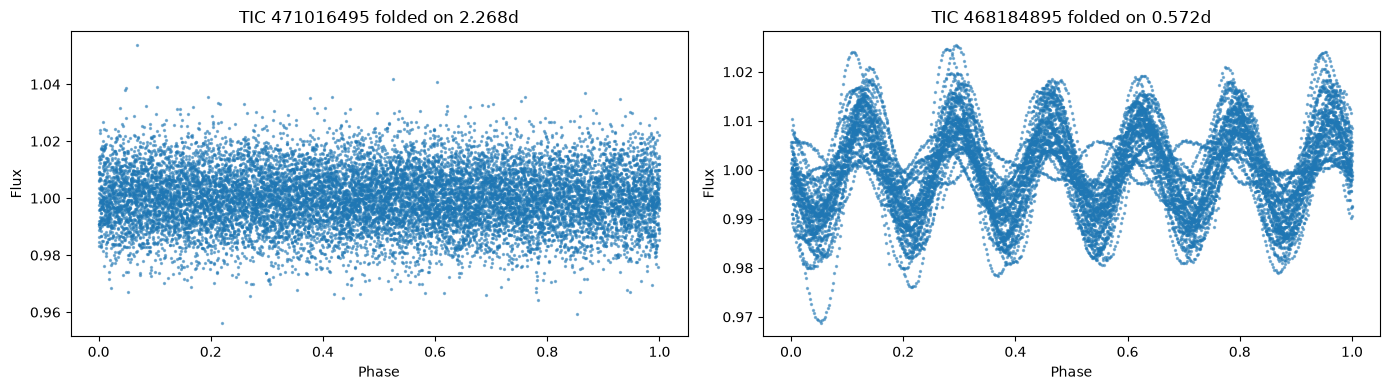

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from detection.detect import load_processed_star

candidates = [
    ("471016495", 2.268),
    ("468184895", 0.572),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (tic_id, period) in zip(axes, candidates):
    time, flux = load_processed_star(f"data/processed/TIC_{tic_id}.npy")
    phase = (time % period) / period
    sort_idx = np.argsort(phase)
    ax.scatter(phase[sort_idx], flux[sort_idx], s=2, alpha=0.5)
    ax.set_title(f"TIC {tic_id} folded on {period}d")
    ax.set_xlabel("Phase")
    ax.set_ylabel("Flux")

plt.tight_layout()
plt.show()

In [1]:
import sys
sys.path.insert(0, ".")
from detection.detect import run_bls_all
from detection.fold import fold_all_candidates

# Re-run detection on your full 93-star dataset
detect_result = run_bls_all()
print(detect_result)

# Fold whatever candidates were found
fold_result = fold_all_candidates()
print(fold_result)

Found 93 processed stars. Running BLS on each...
[1/93] TIC 257710733: not significant (power=0.00005)
[2/93] TIC 257738202: not significant (power=0.00003)
[3/93] TIC 267168728: not significant (power=0.00002)
[4/93] TIC 267194964: not significant (power=0.00000)
[5/93] TIC 270278779: not significant (power=0.00001)
[6/93] TIC 274228124: not significant (power=0.00001)
[7/93] TIC 274228389: not significant (power=0.00002)
[8/93] TIC 279799236: not significant (power=0.00003)
[9/93] TIC 290356320: not significant (power=0.00000)
[10/93] TIC 290492819: not significant (power=0.00001)
[11/93] TIC 290548579: CANDIDATE (power=0.56203, period=3.093d)
[12/93] TIC 290550782: not significant (power=0.00001)
[13/93] TIC 290558713: not significant (power=0.00021)
[14/93] TIC 290558879: not significant (power=0.00006)
[15/93] TIC 290604384: not significant (power=0.00007)
[16/93] TIC 302994978: not significant (power=0.00024)
[17/93] TIC 317154919: not significant (power=0.00001)
[18/93] TIC 3172

KeyboardInterrupt: 

In [2]:
import sys
sys.path.insert(0, ".")
from detection.detect import run_bls_all
from detection.fold import fold_all_candidates

# Re-run detection on your full 93-star dataset
detect_result = run_bls_all()
print(detect_result)

# Fold whatever candidates were found
fold_result = fold_all_candidates()
print(fold_result)

Found 93 processed stars. Running BLS on each...
[1/93] TIC 257710733: not significant (power=0.00005)
[2/93] TIC 257738202: not significant (power=0.00003)
[3/93] TIC 267168728: not significant (power=0.00002)
[4/93] TIC 267194964: not significant (power=0.00000)
[5/93] TIC 270278779: not significant (power=0.00001)
[6/93] TIC 274228124: not significant (power=0.00001)
[7/93] TIC 274228389: not significant (power=0.00002)
[8/93] TIC 279799236: not significant (power=0.00003)
[9/93] TIC 290356320: not significant (power=0.00000)
[10/93] TIC 290492819: not significant (power=0.00001)
[11/93] TIC 290548579: CANDIDATE (power=0.56203, period=3.093d)
[12/93] TIC 290550782: not significant (power=0.00001)
[13/93] TIC 290558713: not significant (power=0.00021)
[14/93] TIC 290558879: not significant (power=0.00006)
[15/93] TIC 290604384: not significant (power=0.00007)
[16/93] TIC 302994978: not significant (power=0.00024)
[17/93] TIC 317154919: not significant (power=0.00001)
[18/93] TIC 3172

In [3]:
with open("results/candidate_ids.txt") as f:
    ids = f.read().strip().split("\n")

print("HD 110082 (TIC 383390264) in candidates:", "383390264" in ids)
print()
print("All 17 candidate IDs:")
for tic_id in ids:
    print(tic_id)

HD 110082 (TIC 383390264) in candidates: False

All 17 candidate IDs:
290548579
325610193
327831847
369768134
369894394
369960846
383381662
394820224
410305216
419637885
419666736
451604550
461738957
468148930
468155076
468184895
471016495


In [4]:
    import sys
sys.path.insert(0, ".")
from detection.detect import run_bls, load_processed_star

time, flux = load_processed_star("data/processed/TIC_383390264.npy")
result = run_bls(time, flux)
print("HD 110082 BLS result:")
print(f"  Detected period: {result['period']:.4f} days (published: 10.1827 days)")
print(f"  Power score: {result['power']:.5f} (your threshold: 0.0005)")
print(f"  Depth: {result['depth']:.5f}")
print(f"  Was it flagged as candidate? {result['power'] >= 0.0005}")

IndentationError: unexpected indent (524992136.py, line 1)

In [5]:
import sys
sys.path.insert(0, ".")
from detection.detect import run_bls, load_processed_star

time, flux = load_processed_star("data/processed/TIC_383390264.npy")
result = run_bls(time, flux)
print("HD 110082 BLS result:")
print(f"  Detected period: {result['period']:.4f} days (published: 10.1827 days)")
print(f"  Power score: {result['power']:.5f} (your threshold: 0.0005)")
print(f"  Depth: {result['depth']:.5f}")
print(f"  Was it flagged as candidate? {result['power'] >= 0.0005}")

HD 110082 BLS result:
  Detected period: 10.5572 days (published: 10.1827 days)
  Power score: 0.00002 (your threshold: 0.0005)
  Depth: 0.00037
  Was it flagged as candidate? False


In [1]:
from detection.detect import run_bls_all
run_bls_all()

SyntaxError: 'return' outside function (detect.py, line 103)

In [2]:
from detection.detect import run_bls_all
run_bls_all()

Found 1146 processed stars. Running BLS on each...
[1/1146] TIC 100100827: FAILED - The maximum transit duration must be shorter than the minimum period
[2/1146] TIC 100389539: FAILED - The maximum transit duration must be shorter than the minimum period
[3/1146] TIC 100504381: FAILED - The maximum transit duration must be shorter than the minimum period
[4/1146] TIC 100566492: FAILED - The maximum transit duration must be shorter than the minimum period
[5/1146] TIC 100608026: FAILED - The maximum transit duration must be shorter than the minimum period
[6/1146] TIC 100990000: FAILED - The maximum transit duration must be shorter than the minimum period
[7/1146] TIC 101011575: FAILED - The maximum transit duration must be shorter than the minimum period
[8/1146] TIC 101929303: FAILED - The maximum transit duration must be shorter than the minimum period
[9/1146] TIC 101948569: FAILED - The maximum transit duration must be shorter than the minimum period
[10/1146] TIC 102068384: FAILED

{'total': 1146, 'candidates': 0}

In [3]:
from detection.detect import run_bls_all, run_bls, load_processed_star, list_processed_files, extract_tic_id

# First check power distribution with new settings
files = list_processed_files()
print(f"Total files: {len(files)}")

powers = []
for filepath in files[:10]:  # check first 10
    tic_id = extract_tic_id(filepath)
    try:
        time, flux = load_processed_star(filepath)
        result = run_bls(time, flux)
        powers.append(result['power'])
        print(f"  TIC {tic_id}: power={result['power']:.6f}  period={result['period']:.3f}d")
    except Exception as e:
        print(f"  TIC {tic_id}: error {e}")

print(f"\nPower distribution:")
print(f"  Max    : {max(powers):.6f}")
print(f"  Min    : {min(powers):.6f}")
print(f"  Median : {sorted(powers)[len(powers)//2]:.6f}")
print(f"\nCurrent threshold: 0.0005")
print(f"Stars above threshold: {sum(1 for p in powers if p >= 0.0005)}")
print(f"\nSuggested threshold: {min(powers)*2:.6f}")

Total files: 1146
  TIC 100100827: error The maximum transit duration must be shorter than the minimum period
  TIC 100389539: error The maximum transit duration must be shorter than the minimum period
  TIC 100504381: error The maximum transit duration must be shorter than the minimum period
  TIC 100566492: error The maximum transit duration must be shorter than the minimum period
  TIC 100608026: error The maximum transit duration must be shorter than the minimum period
  TIC 100990000: error The maximum transit duration must be shorter than the minimum period
  TIC 101011575: error The maximum transit duration must be shorter than the minimum period
  TIC 101929303: error The maximum transit duration must be shorter than the minimum period
  TIC 101948569: error The maximum transit duration must be shorter than the minimum period
  TIC 102068384: error The maximum transit duration must be shorter than the minimum period

Power distribution:


ValueError: max() iterable argument is empty

In [4]:
from detection.detect import run_bls_all, run_bls, load_processed_star, list_processed_files, extract_tic_id

# First check power distribution with new settings
files = list_processed_files()
print(f"Total files: {len(files)}")

powers = []
for filepath in files[:10]:  # check first 10
    tic_id = extract_tic_id(filepath)
    try:
        time, flux = load_processed_star(filepath)
        result = run_bls(time, flux)
        powers.append(result['power'])
        print(f"  TIC {tic_id}: power={result['power']:.6f}  period={result['period']:.3f}d")
    except Exception as e:
        print(f"  TIC {tic_id}: error {e}")

print(f"\nPower distribution:")
print(f"  Max    : {max(powers):.6f}")
print(f"  Min    : {min(powers):.6f}")
print(f"  Median : {sorted(powers)[len(powers)//2]:.6f}")
print(f"\nCurrent threshold: 0.0005")
print(f"Stars above threshold: {sum(1 for p in powers if p >= 0.0005)}")
print(f"\nSuggested threshold: {min(powers)*2:.6f}")

Total files: 1146
  TIC 100100827: error The maximum transit duration must be shorter than the minimum period
  TIC 100389539: error The maximum transit duration must be shorter than the minimum period
  TIC 100504381: error The maximum transit duration must be shorter than the minimum period
  TIC 100566492: error The maximum transit duration must be shorter than the minimum period
  TIC 100608026: error The maximum transit duration must be shorter than the minimum period
  TIC 100990000: error The maximum transit duration must be shorter than the minimum period
  TIC 101011575: error The maximum transit duration must be shorter than the minimum period
  TIC 101929303: error The maximum transit duration must be shorter than the minimum period
  TIC 101948569: error The maximum transit duration must be shorter than the minimum period
  TIC 102068384: error The maximum transit duration must be shorter than the minimum period

Power distribution:


ValueError: max() iterable argument is empty

In [5]:
import numpy as np
from astropy.timeseries import BoxLeastSquares

# Load one star directly
data   = np.load('data/processed/TIC_100100827.npy', allow_pickle=True).item()
time   = np.asarray(data['time'], dtype=np.float64)
flux   = np.asarray(data['flux'], dtype=np.float64)

print(f"Time range: {time.min():.2f} to {time.max():.2f} days")
print(f"Total points: {len(time)}")
print(f"Duration: {time.max()-time.min():.2f} days")

# Run BLS with safe durations
min_period    = 0.5
max_period    = 27.0
duration_grid = [0.01, 0.02, 0.05, 0.1]  # all less than 0.5/2 = 0.25

print(f"\nDuration grid: {duration_grid}")
print(f"All durations < min_period/2 ({min_period/2}): {all(d < min_period/2 for d in duration_grid)}")

model       = BoxLeastSquares(time, flux)
periodogram = model.autopower(
    duration_grid,
    minimum_period = min_period,
    maximum_period = max_period,
)

best_idx = np.argmax(periodogram.power)
print(f"\nBest period : {periodogram.period[best_idx]:.4f} days")
print(f"Best power  : {periodogram.power[best_idx]:.6f}")
print(f"\nTop 5 powers: {sorted(periodogram.power, reverse=True)[:5]}")

Time range: 1354.11 to 1381.52 days
Total points: 18299
Duration: 27.41 days

Duration grid: [0.01, 0.02, 0.05, 0.1]
All durations < min_period/2 (0.25): True

Best period : 0.9414 days
Best power  : 0.064099

Top 5 powers: [np.float64(0.06409948920057194), np.float64(0.06409409251607592), np.float64(0.06409022890624182), np.float64(0.06409002185817458), np.float64(0.06408008612353532)]


In [6]:
# Reload the module fresh
import importlib
import detection.detect as detect_module
importlib.reload(detect_module)

# Check what's in the function now
import inspect
print(inspect.getsource(detect_module.run_bls))

def run_bls(time, flux, min_period=0.3, max_period=27.0):
    """
    Runs the BLS algorithm on one star's light curve to search for a
    repeating periodic dip.

    Args:
        time (np.ndarray): time values in days (BTJD), from M1's output
        flux (np.ndarray): normalized flux values, from M1's output
        min_period (float): shortest orbital period to search for, in days.
        max_period (float): longest orbital period to search for, in days.

    Returns:
        dict with keys:
            period (float): best-fit orbital period in days
            power (float): BLS power score
            depth (float): fractional flux drop during transit
            duration (float): transit duration in days
            t0 (float): time of the first transit center (BTJD)
            alt_periods (list): alternative periods to try
    """
    duration_grid = [0.01, 0.02, 0.05, 0.1, 0.15, 0.2]
    duration_grid = [d for d in duration_grid if d < min_period * 0.5]

    model = BoxLea

In [ ]:
# Clear Python cache and reload
import shutil, os

# Delete pycache
cache_path = 'detection/__pycache__'
if os.path.exists(cache_path):
    shutil.rmtree(cache_path)
    print("Cleared cache")

# Now reimport fresh
import importlib
import sys

# Remove old module from memory
if 'detection.detect' in sys.modules:
    del sys.modules['detection.detect']
if 'detection' in sys.modules:
    del sys.modules['detection']

# Fresh import
from detection.detect import run_bls_all
result = run_bls_all(power_threshold=0.005)
print(result)

Cleared cache
Found 1146 processed stars. Running BLS on each...


In [ ]:
import subprocess
result = subprocess.run(
    ['python', 'detection/run_bls_fast.py'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

In [1]:
import os
import csv
import numpy as np
import time as time_module

PROCESSED_DIR   = "data/processed"
RESULTS_DIR     = "results"
CANDIDATES_PATH = os.path.join(RESULTS_DIR, "candidates.csv")
POWER_THRESHOLD = 0.005

os.makedirs(RESULTS_DIR, exist_ok=True)

files = sorted([
    os.path.join(PROCESSED_DIR, f)
    for f in os.listdir(PROCESSED_DIR)
    if f.endswith('.npy') and
    not os.path.isdir(os.path.join(PROCESSED_DIR, f))
])
print(f"Total stars: {len(files)}")

candidates = []
all_powers = []
start      = time_module.time()

for i, filepath in enumerate(files):
    tic_id = os.path.basename(filepath).replace('TIC_','').replace('.npy','')
    try:
        data = np.load(filepath, allow_pickle=True).item()
        time = np.asarray(data['time'], dtype=np.float64)
        flux = np.asarray(data['flux'], dtype=np.float64)

        mask = np.isfinite(time) & np.isfinite(flux)
        time, flux = time[mask], flux[mask]
        if len(time) < 200:
            continue

        # ── Fastest BLS approach ──────────────────────────────────
        # Use fewer periods and durations → much faster
        from astropy.timeseries import BoxLeastSquares

        model = BoxLeastSquares(time, flux)

        # Only 2 durations and coarse period grid → 10x faster
        result = model.autopower(
            [0.05, 0.1],              # just 2 durations
            minimum_period = 0.5,
            maximum_period = 15.0,
            frequency_factor = 2.0,   # coarser grid = faster
        )

        best_idx = np.argmax(result.power)
        best_p   = float(result.period[best_idx])
        power    = float(result.power[best_idx])

        all_powers.append(power)

        if power >= POWER_THRESHOLD:
            candidates.append({
                'TIC_ID'       : tic_id,
                'period_days'  : best_p,
                'power'        : power,
                'depth'        : float(result.depth[best_idx]),
                'duration_days': float(result.duration[best_idx]),
                't0'           : float(result.transit_time[best_idx]),
            })

    except Exception as e:
        continue

    if (i+1) % 100 == 0:
        elapsed   = time_module.time() - start
        remaining = (len(files)-i-1) / ((i+1)/elapsed)
        print(f"  [{i+1}/{len(files)}] "
              f"candidates={len(candidates)} | "
              f"{elapsed/60:.1f}min elapsed | "
              f"~{remaining/60:.1f}min left")

# Save
with open(CANDIDATES_PATH, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['TIC_ID','period_days','power',
                     'depth','duration_days','t0'])
    for c in sorted(candidates, key=lambda x: x['power'], reverse=True):
        writer.writerow([
            c['TIC_ID'], c['period_days'], c['power'],
            c['depth'], c['duration_days'], c['t0']
        ])

elapsed = time_module.time() - start
print(f"\n✓ Done in {elapsed/60:.1f} minutes!")
print(f"  Stars     : {len(all_powers)}")
print(f"  Candidates: {len(candidates)}")

if all_powers:
    ps = sorted(all_powers, reverse=True)
    print(f"  Top 5 powers: {[round(p,5) for p in ps[:5]]}")
    print(f"  Median power: {ps[len(ps)//2]:.5f}")

print(f"\n✓ Saved → {CANDIDATES_PATH}")

Total stars: 1146
  [100/1146] candidates=23 | 2.0min elapsed | ~21.0min left
  [200/1146] candidates=42 | 4.0min elapsed | ~18.9min left
  [300/1146] candidates=58 | 6.2min elapsed | ~17.4min left
  [400/1146] candidates=73 | 8.6min elapsed | ~16.0min left
  [500/1146] candidates=93 | 10.7min elapsed | ~13.8min left
  [600/1146] candidates=108 | 12.7min elapsed | ~11.6min left
  [700/1146] candidates=127 | 14.8min elapsed | ~9.4min left
  [800/1146] candidates=146 | 16.9min elapsed | ~7.3min left
  [900/1146] candidates=164 | 18.8min elapsed | ~5.1min left
  [1000/1146] candidates=180 | 20.9min elapsed | ~3.0min left
  [1100/1146] candidates=205 | 22.9min elapsed | ~1.0min left

✓ Done in 23.8 minutes!
  Stars     : 1146
  Candidates: 217
  Top 5 powers: [161.09731, 61.53187, 57.67676, 47.57877, 39.65791]
  Median power: 0.00015

✓ Saved → results\candidates.csv


In [2]:
from detection.fold import fold_all_candidates
result = fold_all_candidates()
print(result)

Folding 217 candidates...
[1/217] TIC 302771290: folded successfully
[2/217] TIC 172171873: folded successfully
[3/217] TIC 49547177: folded successfully
[4/217] TIC 409319605: folded successfully
[5/217] TIC 37435039: folded successfully
[6/217] TIC 1981621672: folded successfully
[7/217] TIC 358232450: folded successfully
[8/217] TIC 148158540: folded successfully
[9/217] TIC 323292655: folded successfully
[10/217] TIC 1102093577: folded successfully
[11/217] TIC 357358259: folded successfully
[12/217] TIC 457173024: folded successfully
[13/217] TIC 420116962: folded successfully
[14/217] TIC 149861542: folded successfully
[15/217] TIC 254003502: folded successfully
[16/217] TIC 259901124: folded successfully
[17/217] TIC 396903513: folded successfully
[18/217] TIC 32268776: folded successfully
[19/217] TIC 365089053: folded successfully
[20/217] TIC 283819432: folded successfully
[21/217] TIC 270622446: folded successfully
[22/217] TIC 229804573: folded successfully
[23/217] TIC 508